In [182]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [183]:
# Lista para alocar os dados da contagem de partículas
particulas = []

# Função para contar a quantidade de partículas em cada linha TRIG
def contar_particulas(evento):
    contagem = {}
    for linha in evento:
        partes = linha.split()
        if partes[0].startswith("TRIG"):
            contagem[partes[0]] = len(partes) - 1  
    return contagem

# Função para processar o arquivo e contar as partículas em cada evento
def contar_particulas_em_eventos(nome_arquivo):
    with open(nome_arquivo, 'r') as arquivo:
        linhas = arquivo.readlines()
    
    eventos = []
    evento_atual = []
    
    for linha in linhas:
        if linha.startswith("EVTE"):
            eventos.append(evento_atual)
            evento_atual = []
        evento_atual.append(linha)
    
    # Contagem da quantidade de partículas em cada linha TRIG em cada evento
    for i, evento in enumerate(eventos):
        contagem = contar_particulas(evento)
        #print(f"Evento {i + 1}:")
        for linha_trig, quantidade in contagem.items():
            #print(f"{linha_trig}: {quantidade} partículas")
            particulas.append(contagem)

if __name__ == "__main__":
    arquivo = "iron4.64E15"  
    contar_particulas_em_eventos(arquivo)


In [184]:
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5

trig1 = []
trig2 = []
trig3 = []

#type(particulas[20])

In [185]:
trigs = []
for i in particulas:
    trigs_aux = list(i.values())
    trigs.append(trigs_aux)

In [186]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig1.append(sublista[0])

In [187]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig2.append(sublista[1])

In [188]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig3.append(sublista[2])

In [189]:
print(trig1,'\n',
      trig2,'\n',
      trig3)

[98, 105, 117, 64, 123, 129, 80, 101, 87, 86, 149, 152, 67, 156, 83, 142, 95, 211, 109, 125, 179, 157, 116, 58, 148, 207, 85, 69, 145, 74, 53, 54, 184, 93, 94, 248, 51, 114, 146, 120, 82, 81, 125, 217, 58, 224, 71, 197, 72, 156, 91, 131, 38, 49, 71, 161, 85, 66, 67, 145, 114, 142, 84, 119, 175, 89, 205, 137, 92, 88, 91, 44, 83, 155, 89, 104, 176, 117, 132, 77, 96, 161, 67, 179, 96, 117, 100, 112, 49, 105, 116, 58, 203, 119, 89, 112, 52, 45, 179, 122] 
 [111, 84, 102, 37, 92, 119, 54, 64, 66, 125, 96, 126, 43, 135, 61, 82, 75, 137, 94, 118, 156, 139, 95, 76, 76, 130, 85, 104, 129, 58, 36, 84, 117, 70, 73, 202, 69, 115, 112, 89, 53, 72, 79, 137, 53, 130, 53, 110, 61, 114, 81, 97, 28, 57, 59, 119, 82, 60, 55, 125, 69, 124, 66, 81, 103, 93, 119, 115, 82, 64, 35, 38, 53, 111, 72, 83, 127, 105, 106, 54, 60, 148, 86, 124, 66, 81, 87, 92, 37, 75, 87, 57, 126, 87, 74, 69, 57, 55, 122, 88] 
 [114, 101, 76, 57, 83, 124, 72, 82, 73, 98, 120, 132, 47, 111, 68, 112, 98, 140, 98, 100, 171, 114, 78, 4

In [190]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [191]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.034833,-78.533217,113.51,88.39,88.88,83.193811,0.008552,0.006659,0.006696,425.222615,481.884038,482.249321


In [192]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)


data2 = {
    'rho':rho,
    'r_b':r_b
}

df3 = pl.DataFrame(data2)
df3.write_csv('bary_dat/' + arquivo + '_bary.csv', separator= '\t', has_header= False)

[0.008551800042774454, 0.006659268837818996, 0.006696185250654511] [425.22261481059394, 481.8840383608097, 482.2493209072665]


In [193]:
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Iron 4.64E15'

/tmp/ipykernel_6362/4272195868.py:18: RuntimeWarning: overflow encountered in power
  return np.array(((c/r0**2)*(x/r0)**(s-2)*(1+x/r0)**(s-4.5)))
/tmp/ipykernel_6362/4272195868.py:18: RuntimeWarning: invalid value encountered in power
  return np.array(((c/r0**2)*(x/r0)**(s-2)*(1+x/r0)**(s-4.5)))
/home/orfei/.local/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


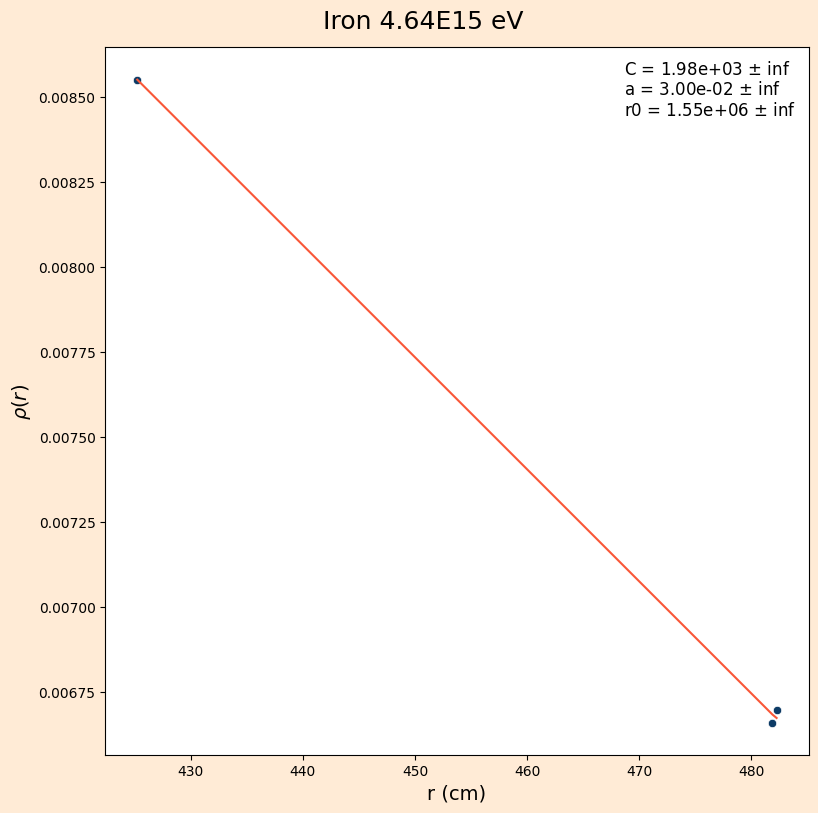

In [194]:
# Essa modelagem não está certa!

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle(str(name) + ' eV', size = 18)
sns.scatterplot(x = r_b, y = rho, ax = ax, color = '#0D3B66')
fig.tight_layout()

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho(r)$', size = 14)

#ax.set_xlim(xmin=0)
#ax.set_ylim(ymin=0)


#r0 = 7800
p0 = (1000,1.334,7800)
def f_model(x, c, s,r0):
    return np.array(((c/r0**2)*(x/r0)**(s-2)*(1+x/r0)**(s-4.5)))

popt, pcov = curve_fit(
    f=f_model,       
    xdata=r_b,   
    ydata=rho,   
    p0=p0,
    maxfev = 12000
    #bounds= 
    #sigma=df["Dy"]   
)
c_opt, s_opt , r0_opt = popt

inc = np.sqrt(np.diag(pcov))

y = f_model(r_b,c_opt, s_opt, r0_opt)

plt.plot(r_b, y, color = '#F95738')

ax.legend(title = 'C = {:.2e} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nr0 = {:.2e} $\pm$ {:.2e}'
          .format(c_opt,inc[0],s_opt,inc[1],r0_opt,inc[2]),
          title_fontsize = 12, facecolor = 'white', frameon = False)

#plt.savefig('plots/fit_' + str(arquivo) + '.png',bbox_inches = 'tight')

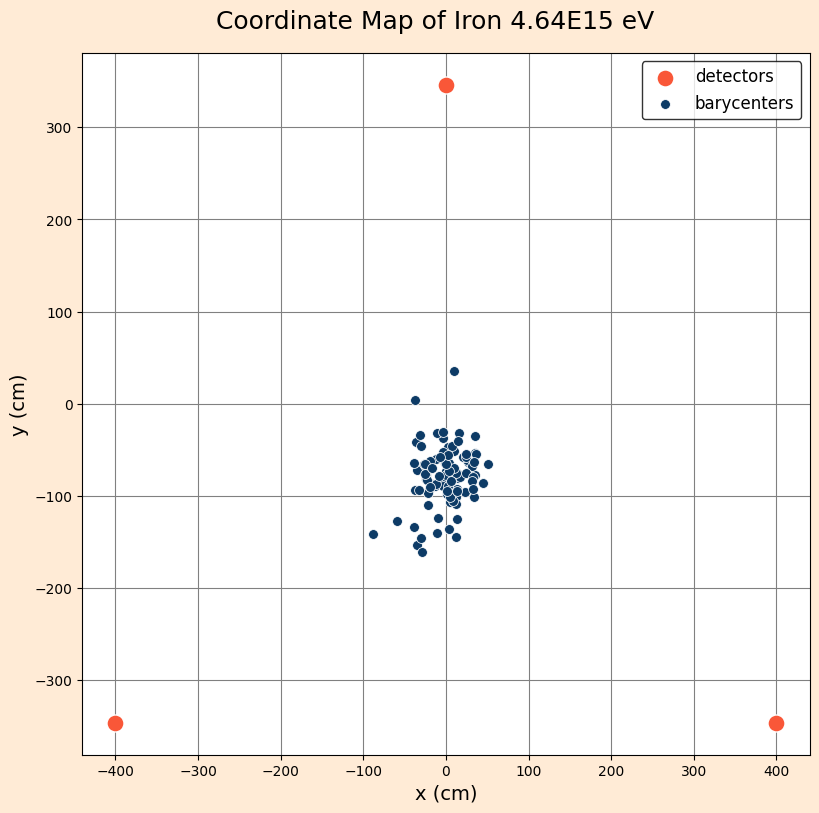

In [195]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [196]:
# Comparação do número de partículas no tanque com a distribuição lateral do Corsika com r = 346 cm

Energy = {'1E13':0,'1E14':1, '2.15E14':2, '4.64E14':3,'1E15':4,'2.15E15':5,'4.64E15':6}
Particle = ['Photon','Proton','Iron']
radius = 65
N_tanque = []

rho_photon = [3.77691e-06,0.000124827, 0.000601522, 0.00155853,0.00552918,0.0168817,0.0541952]
rho_proton = [8.32333e-06,0.000198282, 0.000696983, 0.00154504,0.00568147,0.0121761,0.0342564]
rho_iron = [0,9.83903e-06, 4.31253e-05, 0.000181546,0.000857134,0.00266104,0.00917539]

print(name.split()[0])
print(name.split()[1])

print(Energy.get(name.split()[1]))
aux = Energy.get(name.split()[1])


if name.split()[0] == 'Photon':
        N_tanque = rho_photon[aux]*math.pi*radius**2
elif name.split()[0] == 'Proton':
        N_tanque = rho_proton[aux]*math.pi*radius**2
elif name.split()[0] == 'Iron':
        N_tanque = rho_iron[aux]*math.pi*radius**2

N_1 = df2['rho1'][0]*math.pi*65**2
N_2 = df2['rho2'][0]*math.pi*65**2
N_3 = df2['rho3'][0]*math.pi*65**2


print('Número de partículas em cada tanque:', N_tanque,
       '\nNúmero de partículas no tanque 1:', N_1,
       '\nNúmero de partículas no tanque 2:', N_2,
       '\nNúmero de partículas no tanque 3:', N_3)

data = {'Particle': [name.split()[0]],
         'Energy': [name.split()[1]],
         'N_detector': [N_tanque],
          'N_det_1': [N_1],
         'N_det_2': [N_2], 
         'N_det_3': [N_3]}

df = pd.DataFrame(data)

#df.to_csv('particles_detectors.csv', index = False)
#df.to_csv('particles_detectors.csv', mode = 'a', index = False, header = False)

Iron
4.64E15
6
Número de partículas em cada tanque: 121.78705228029479 
Número de partículas no tanque 1: 113.50999999999996 
Número de partículas no tanque 2: 88.39 
Número de partículas no tanque 3: 88.87999999999998


In [197]:
#df = pd.read_csv('particles_detectors.csv')
#df

In [219]:
# Reconstrução da energia

E_real = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
r0 = 7800

# Parâmetros fóton

k_photon = 6.59E-17 #+- 3.82E-17
p_photon = 1.39 #+- 0.02
c_photon = [1975,5697,1.539E4,4.969E4,1.368E5,4.35E5]
s_photon = [1.506,1.303,1.364,1.334,1.307,1.304]
E_photon = []
N_photon = []

for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)
    N = ((c_photon[i])/((r0**(s_photon[i]))))*(1000**((s_photon[i]-1))/(s_photon[i]-1))*math.pi*1000**2
    N_photon.append(N)
    #print('{:e}'.format(E_photon[i]))


# Parâmetros próton

k_proton = 3.02E-14
p_proton = 1.21
c_proton = [2894,6269,1.609E4,4.776E4,1.028E5,2.606E5]
s_proton = [1.481,1.348,1.407,1.317,1.326,1.285]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)
    #print('{:e}'.format(E_proton[i]))

# Parâmetros ferro

k_iron = 2.42E-17
p_iron = 1.39
c_iron = [293.8,3226,6020,1.778E4,5.223E4,1.058E5]
s_iron = [2.033,2.097,1.778,1.645,1.606,1.431]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    #print('{:e}'.format(E_iron[i]))


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_iron
f64,f64,f64,f64
1.0000e14,1.0280e14,1.0822e14,5.3662e13
2.1500e14,2.2029e14,2.0499e14,3.0082e14
4.6400e14,4.5029e14,4.4673e14,4.7122e14
1.0000e15,1.0464e15,1.0979e15,1.0271e15
2.1500e15,2.1683e15,2.0687e15,2.2299e15
4.6400e15,4.9838e15,4.4623e15,3.7053e15


In [220]:
import glob 

output_path = '/home/orfei/mestrado/progs/lateral_distribution/eletrons/data/photon/*'

N_t = []

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'N_real':N_t,
    'N_photon':N_photon
}

df = pl.DataFrame(data)
df


N_real,N_photon
i64,f64
228671,555996.405851
826376,4.0640e6
2192990,8.0625e6
6815668,3.0173e7
18687763,9.5528e7
54938489,3.0866e8


In [ ]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = np.log10(E), y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_c, color = '#700353', ax = ax)


In [199]:
c = 1824
s = 1.521
r0 = 7800

((c)/((r0**(s))))*(500**((s-1))/(s-1))*math.pi*500**2

84248.94547777793